<a href="https://colab.research.google.com/github/sourabhverma1302/AI-ML-Journey/blob/main/SciKit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   bedrooms  bathrooms  land_size_sqm  distance_to_cbd  house_age   price
0         4          2            319               31         25   61410
1         5          2            257                1         43  302586
2         3          2            545                3         24  287871
3         5          3            673               16         16  368259
4         5          3            316               23         12  242796
[ 157254.36235814  152474.63034087   25170.65438041  113864.65753676
  169077.80567573  390061.77908094  248962.32925038  -28882.39375819
  292601.05133056   79889.40416081  134853.34560197  120890.68532248
   55081.57867009  334586.57414372  290675.73902149   -7884.86718238
  401141.61703072   -2558.41031798  177576.36494211  -26096.35097976
    6967.41774392  216821.04479032   89345.73766494  166993.78320607
  374768.85115656  238820.37142883  110909.4935398  -107039.75675468
  179860.33366988  394063.8230552   239821.91709401  -83930.15688133
  -6

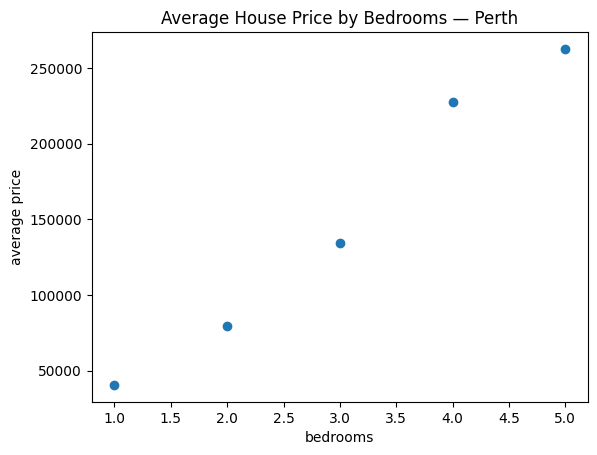

Accuracy: 0.975
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        38
           1       1.00      0.50      0.67         2

    accuracy                           0.97        40
   macro avg       0.99      0.75      0.83        40
weighted avg       0.98      0.97      0.97        40



In [58]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


np.random.seed(42)
n = 200

data = {
    "bedrooms":        np.random.randint(1, 6, n),
    "bathrooms":       np.random.randint(1, 4, n),
    "land_size_sqm":   np.random.randint(200, 800, n),
    "distance_to_cbd": np.random.randint(1, 40, n),  # km from Perth CBD
    "house_age":       np.random.randint(0, 50, n),
    "price":           None  # you will generate this
}

df = pd.DataFrame(data)

# Price is based on real logic — not random!
df["price"] = (
    df["bedrooms"]        * 50000 +
    df["bathrooms"]       * 30000 +
    df["land_size_sqm"]   * 300   +
    df["distance_to_cbd"] * -8000 +  # further = cheaper
    df["house_age"]       * -2000 +  # older = cheaper
    np.random.randint(-20000, 20000, n)  # some noise
)

print(df.head())

X = df[["bedrooms", "bathrooms", "land_size_sqm", "distance_to_cbd", "house_age"]]
y=df["price"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#train model

model=LinearRegression()
model.fit(X_train,y_train)


y_pred=model.predict(X_test)
print(y_pred)


print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

avg_price=df.groupby('bedrooms')['price'].mean()
print(avg_price)

plt.scatter(avg_price.index,avg_price.values)
plt.xlabel("bedrooms")
plt.ylabel("average price")
plt.title("Average House Price by Bedrooms — Perth")
plt.show()


# Model 2 — Logistic Regression
df["expensive"] = (df["price"] > 400000).astype(int)

X = df[["bedrooms", "bathrooms", "land_size_sqm", "distance_to_cbd", "house_age"]]
y = df["expensive"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model2 = LogisticRegression()
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2))


# print(df.describe())